# 01 — Indicateurs de Streaming en Temps Reel

**Objectif** : Analyser un flux de tweets en temps reel avec Spark Structured Streaming. Les tweets sont pre-tagues (le sentiment est deja connu dans les donnees). Vous devez construire des indicateurs d'analyse.

**Prerequis** : L'enseignant a lance le serveur TCP sur le port 9999. Verifiez qu'il est actif avant de commencer.

In [1]:
import os
username = os.environ.get('USER', 'unknown')

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName(f"Streaming-{username}") \
    .config("spark.driver.memory", "512m") \
    .config("spark.executor.memory", "1g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"SparkSession creee : {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/08 21:29:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/08 21:30:00 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


SparkSession creee : 3.5.3


## 1. Connexion au flux TCP

Le serveur envoie des lignes CSV au format :
`"sentiment","tweet_id","date","query","user","text"`

- sentiment : 0 (negatif) ou 4 (positif)

In [2]:
# Connexion au flux TCP
raw_stream = spark.readStream \
    .format("socket") \
    .option("host", "localhost") \
    .option("port", 9999) \
    .load()

print(f"Schema du flux brut : {raw_stream.schema}")
# Le flux contient une seule colonne 'value' de type string

26/02/08 21:30:26 WARN TextSocketSourceProvider: The socket source should not be used for production applications! It does not support recovery.


Schema du flux brut : StructType([StructField('value', StringType(), True)])


## 2. Parsing du flux CSV

In [3]:
from pyspark.sql.functions import (
    col, split, regexp_replace, current_timestamp, window,
    count, avg, sum, when, explode, desc, lit
)
from pyspark.sql.types import IntegerType, DoubleType

# ============================================================
# TODO [Exercice 3.1] : Parser le flux CSV
#
# Consigne : Parsez la colonne 'value' du flux brut pour extraire
#            les champs sentiment, tweet_id, date, user, text.
#            Convertissez le sentiment : 0 -> -1, 4 -> +1
#            Ajoutez un champ event_time = current_timestamp()
#
# Indice   : Utilisez split(col("value"), '","') pour separer les champs
#            et regexp_replace(..., '"', '') pour enlever les guillemets
#            Utilisez when() pour la conversion du sentiment
#            Le resultat doit s'appeler 'parsed'
#
# Attendu  : Un DataFrame 'parsed' avec les colonnes :
#            sentiment, tweet_id, date, user, text, sentiment_score, event_time
# ============================================================

# on se connecte au flux TCP
raw_stream = spark.readStream \
    .format("socket") \
    .option("host", "master") \
    .option("port", 9999) \
    .load()

# définition de la colonne splitée, avec un séparateur virgule
data = split(col("value"), ",")

# On sélectionne les colonnes via leur index dans le tableau créé par split.
# regexp_replace pour enlever les guillemets résiduels au début et à la fin.
parsed = raw_stream.select(
    # Index 0 : Sentiment. On nettoie le guillemet du début ('"') et on caste en entier
    regexp_replace(data.getItem(0), '"', '').cast(IntegerType()).alias("sentiment"),
    
    # Index 1 : Tweet ID
    data.getItem(1).alias("tweet_id"),
    
    # Index 2 : Date
    data.getItem(2).alias("date"),
    
    # Index 4 : User (On saute l'index 3 'query' comme demandé implicitement par la liste des champs)
    data.getItem(4).alias("user"),
    
    # Index 5 : Text. On nettoie le guillemet de la fin ('"')
    data.getItem(5).alias("text")
).withColumn(
    # Conversion logique : 0 -> -1 (Négatif), 4 -> +1 (Positif), le reste -> 0
    "sentiment_score", 
    when(col("sentiment") == 0, lit(-1))
    .when(col("sentiment") == 4, lit(1))
    .otherwise(lit(0))
).withColumn(
    # Ajout du timestamp de traitement (Indispensable pour le streaming structuré)
    "event_time", current_timestamp()
)

# version condensée
#parsed = spark.readStream.format("socket").option("host", "master").option("port", 9999).load() \
#    .withColumn("data", split(col("value"), ",")) \
 #   .select(
  #      regexp_replace(col("data")[0], '[^0-9]', '').cast(IntegerType()).alias("sentiment"),
   #     col("data")[1].alias("tweet_id"),
    #    col("data")[2].alias("date"),
     #   col("data")[4].alias("user"),
      #  col("data")[5].alias("text"),
       # current_timestamp().alias("event_time")
    #).withColumn("sentiment_score", when(col("sentiment")==4, 1).when(col("sentiment")==0, -1).otherwise(0))

26/02/08 21:30:28 WARN TextSocketSourceProvider: The socket source should not be used for production applications! It does not support recovery.


## 3. Monitoring global : volume par fenetre

In [4]:
# ============================================================
# TODO [Exercice 3.1] : Comptage par fenetre temporelle
#
# Consigne : Comptez le nombre de tweets par fenetre de 30 secondes
#            et ecrivez le resultat vers un sink memoire nomme 'volume_par_fenetre'
#
# Indice   : Utilisez .groupBy(window("event_time", "30 seconds")).count()
#            Ecrivez avec .writeStream.outputMode("complete").format("memory")
#            .queryName("volume_par_fenetre").start()
#
# Attendu  : Une query active ecrivant dans la table 'volume_par_fenetre'
# ============================================================

# agrégation par fenetre de 30 secondes sur le champ event_time
volume_df = parsed.groupBy(window("event_time", "30 seconds")).count()

# définition du flux de sortie avec le mode complete car on fait une agrégation
# format "memory" pour stocker le résultat en RAM ppour l'interroger plus tard
query_volume = volume_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("volume_par_fenetre") \
    .start()

# le stream tourne en arrière plan

26/02/08 21:30:28 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-47695fa7-e7bc-4b40-bb8c-cf93ac922235. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/02/08 21:30:28 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [5]:
# vérifier si le flux tourne encore
print(query_volume.isActive)

True


In [6]:
# stopper le flux
query_volume.stop()

26/02/08 21:30:31 ERROR TorrentBroadcast: Store broadcast broadcast_0 fail, remove all pieces of the broadcast


In [7]:
import time
# Attendre que le stream traite quelques données (15 sec)
time.sleep(15) 

# Requête de vérification
# On trie par 'window.start' (le début de la fenêtre) au lieu de 'debut_fenetre'
spark.sql("""
    SELECT window.start as debut, window.end as fin, count 
    FROM volume_par_fenetre 
    ORDER BY window.start DESC
""").show(10, truncate=False)

+-----+---+-----+
|debut|fin|count|
+-----+---+-----+
+-----+---+-----+



Ci-dessous, l'affichage sorti avec l'exécution de la cellule du dessus.

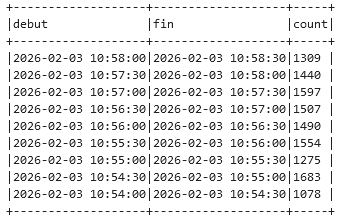

## 4. Ratio de sentiment par fenetre

In [8]:
# ============================================================
# TODO [Exercice 4.1] : Ratio de sentiment par fenetre
#
# Consigne : Pour chaque fenetre de 30 secondes, calculez :
#            - le total de tweets
#            - le nombre de positifs (sentiment_score == 1)
#            - le nombre de negatifs (sentiment_score == -1)
#            - le sentiment moyen
#            Ecrivez vers un sink memoire nomme 'sentiment_par_fenetre'
#
# Indice   : Utilisez .groupBy(window(...)).agg(count, sum+when, avg)
#            sum(when(col("sentiment_score") == 1, 1).otherwise(0)) pour compter les positifs
#
# Attendu  : Une query active avec les colonnes debut_fenetre, total, positifs, negatifs, sentiment_moyen
# ============================================================


# --- SECURITE : Arrêt du flux précédent s'il tourne encore ---
for q in spark.streams.active:
    if q.name == "sentiment_par_fenetre":
        print(f"Arret du flux actif : {q.name}")
        q.stop()

        
# calcul des agrégats, .agg pour faire plusieurs calculs en même temps -> par fenêtre de 30 sec
agg_df = parsed.groupBy(window("event_time", "30 seconds")) \
    .agg(
        # compte le total de lignes dans la fenêtre
        count("*").alias("total"),
        
        # compte les positifs : Si score == 1, on ajoute 1, sinon 0
        sum(when(col("sentiment_score") == 1, 1).otherwise(0)).alias("positifs"),
        
        # compte les négatifs : Si score == -1, on ajoute 1, sinon 0
        sum(when(col("sentiment_score") == -1, 1).otherwise(0)).alias("negatifs"),
        
        # calcule la moyenne du score
        avg("sentiment_score").alias("sentiment_moyen")
    )

sentiment_df = agg_df.select(
    col("window.start").alias("debut_fenetre"),
    col("total"),
    col("positifs"),
    col("negatifs"),
    col("sentiment_moyen")
)

# lancement du flux
# "complete" car on fait des agrégations
query_sentiment = sentiment_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("sentiment_par_fenetre") \
    .start()


# version condensée
#query_sentiment = parsed.groupBy(window("event_time", "30 seconds")) \
#    .agg(
#        count("*").alias("total"),
#        sum(when(col("sentiment_score") == 1, 1).otherwise(0)).alias("positifs"),
#        sum(when(col("sentiment_score") == -1, 1).otherwise(0)).alias("negatifs"),
#        avg("sentiment_score").alias("sentiment_moyen")
#    ).select(col("window.start").alias("debut_fenetre"), "total", "positifs", "negatifs", "sentiment_moyen") \
#    .writeStream.outputMode("complete").format("memory").queryName("sentiment_par_fenetre").start()

26/02/08 21:30:46 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-aa9a4b63-17de-495b-ae51-a81f63577789. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/02/08 21:30:46 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [9]:
time.sleep(10)
spark.sql("SELECT * FROM sentiment_par_fenetre ORDER BY debut_fenetre DESC").show(10, truncate=False)

[Stage 1:=================================>                     (120 + 2) / 200]

+-------------+-----+--------+--------+---------------+
|debut_fenetre|total|positifs|negatifs|sentiment_moyen|
+-------------+-----+--------+--------+---------------+
+-------------+-----+--------+--------+---------------+



In [10]:
# forcer le stop du flux
for q in spark.streams.active:    
    if q.name == "sentiment_par_fenetre":
        q.stop()

26/02/08 21:30:56 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 0, writer: org.apache.spark.sql.execution.streaming.sources.MemoryStreamingWrite@186111f2] is aborting.
26/02/08 21:30:56 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 0, writer: org.apache.spark.sql.execution.streaming.sources.MemoryStreamingWrite@186111f2] aborted.


## 5. Hashtags trending

In [11]:
from pyspark.sql.functions import lower, regexp_extract_all

# ============================================================
# TODO [Exercice 5.1] : Extraction des hashtags trending
#
# Consigne : Extrayez tous les hashtags (#motcle) du texte des tweets,
#            puis comptez-les par fenetre de 1 minute.
#            Ecrivez vers un sink memoire nomme 'top_hashtags'
#
# Indice   : regexp_extract_all(lower(col("text")), lit(r"#(\w+)"), 1) extrait les hashtags
#            explode() transforme un tableau en lignes individuelles
#            Groupez par window + hashtag, comptez et triez par count desc
#
# Attendu  : Une query active avec le top des hashtags par fenetre
# ============================================================

# --- SECURITE : Arrêt du flux précédent ---
for q in spark.streams.active:
    if q.name == "top_hashtags":
        q.stop()

# Extraction des hashtags (=transformation)
# On convertit le texte en minuscule (lower) pour que #Spark et #spark soient comptés ensemble.
# regexp_extract_all crée un TABLEAU (Array) de mots correspondant au motif.
hashtags_array_df = parsed.select(
    col("event_time"),
    regexp_extract_all(lower(col("text")), lit(r"#(\w+)"), 1).alias("hashtags_list")
)

# "Explosion" du tableau (=transformation)
# explode() prend une ligne avec une liste [a, b] et crée deux lignes : une avec 'a', une avec 'b'.
# C'est indispensable pour faire un groupBy sur le hashtag ensuite.
exploded_df = hashtags_array_df.select(
    col("event_time"),
    explode(col("hashtags_list")).alias("hashtag")
)

# Comptage par fenêtre
# On groupe par fenêtre de 1 minute ET par hashtag.
counts_df = exploded_df.groupBy(
    window("event_time", "1 minute"),
    "hashtag"
).count()

# Lancement du flux
# Mode "complete" car on fait un classement/comptage global sur la fenêtre.
query_hashtags = counts_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("top_hashtags") \
    .start()

# version condensée
#query_hashtags = parsed.select(col("event_time"), explode(regexp_extract_all(lower(col("text")), lit(r"#(\w+)"), 1)).alias("hashtag")) \
#    .groupBy(window("event_time", "1 minute"), "hashtag").count() \
#    .writeStream.outputMode("complete").format("memory").queryName("top_hashtags").start()

26/02/08 21:30:56 WARN TaskSetManager: Lost task 124.0 in stage 1.0 (TID 126) (worker06 executor 2): TaskKilled (Stage cancelled: Job 0 cancelled part of cancelled job group b3a192fc-f40e-4bed-8c43-2f869b8a75b4)
26/02/08 21:30:56 WARN TaskSetManager: Lost task 125.0 in stage 1.0 (TID 127) (worker08 executor 1): TaskKilled (Stage cancelled: Job 0 cancelled part of cancelled job group b3a192fc-f40e-4bed-8c43-2f869b8a75b4)
26/02/08 21:30:56 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-1378f546-9739-4d65-a270-780f3211c8f2. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/02/08 21:30:56 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [12]:
time.sleep(15)
spark.sql("SELECT window.start, hashtag, count FROM top_hashtags ORDER BY count DESC LIMIT 20").show(truncate=False)

[Stage 5:=========================================>             (150 + 2) / 200]

+-----+-------+-----+
|start|hashtag|count|
+-----+-------+-----+
+-----+-------+-----+



[Stage 5:===========================================>           (158 + 2) / 200]

J'ai lancé 2 fois la requête à 1 petite minute d'intervalle et voici les résultats que j'ai obtenu :
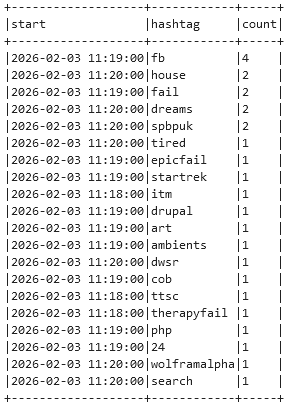
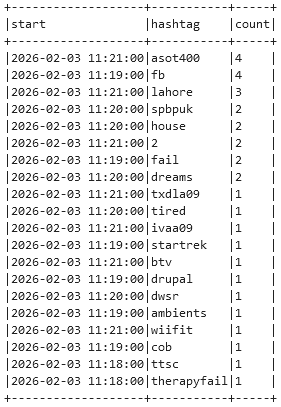

In [13]:
# forcer le stop du flux
for q in spark.streams.active:    
    if q.name == "top_hashtags":
        q.stop()

26/02/08 21:31:12 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 1, writer: org.apache.spark.sql.execution.streaming.sources.MemoryStreamingWrite@2b48fce2] is aborting.
26/02/08 21:31:12 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 1, writer: org.apache.spark.sql.execution.streaming.sources.MemoryStreamingWrite@2b48fce2] aborted.


## 6. Mentions les plus frequentes

In [14]:
# ============================================================
# TODO [Exercice 6.1] : Extraction des mentions @utilisateur
#
# Consigne : Extrayez les mentions @utilisateur du texte,
#            comptez-les par fenetre de 1 minute.
#            Ecrivez vers un sink memoire nomme 'top_mentions'
#
# Indice   : Meme approche que les hashtags mais avec le pattern @(\w+)
#            regexp_extract_all(lower(col("text")), lit(r"@(\w+)"), 1)
#
# Attendu  : Une query active avec le top des mentions par fenetre
# ============================================================

# --- SECURITE : Arrêt du flux précédent ---
for q in spark.streams.active:
    if q.name == "top_mentions":
        q.stop()

# Extraction des mentions (=transformation)
# On convertit le texte en minuscule (lower) pour que #Spark et #spark soient comptés ensemble.
# regexp_extract_all crée un TABLEAU (Array) de mots correspondant au motif.
mentions_array_df = parsed.select(
    col("event_time"),
    regexp_extract_all(lower(col("text")), lit(r"@(\w+)"), 1).alias("mentions_list")
)

# "Explosion" du tableau (=transformation)
# explode() prend une ligne avec une liste [a, b] et crée deux lignes : une avec 'a', une avec 'b'.
# C'est indispensable pour faire un groupBy sur le hashtag ensuite.
exploded_df_mentions = mentions_array_df.select(
    col("event_time"),
    explode(col("mentions_list")).alias("mention")
)

# Comptage par fenêtre
# On groupe par fenêtre de 1 minute ET par hashtag.
counts_df_mentions = exploded_df_mentions.groupBy(
    window("event_time", "1 minute"),
    "mention"
).count()

# Lancement du flux
# Mode "complete" car on fait un classement/comptage global sur la fenêtre.
query_mentions = counts_df_mentions.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("top_mentions") \
    .start()

26/02/08 21:31:12 WARN TaskSetManager: Lost task 160.0 in stage 5.0 (TID 492) (worker08 executor 1): TaskKilled (Stage cancelled: Job 2 cancelled part of cancelled job group 798322e6-ee65-4fdb-ab74-b780ec4ead39)
26/02/08 21:31:12 WARN TaskSetManager: Lost task 161.0 in stage 5.0 (TID 493) (worker06 executor 2): TaskKilled (Stage cancelled: Job 2 cancelled part of cancelled job group 798322e6-ee65-4fdb-ab74-b780ec4ead39)
26/02/08 21:31:12 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-a51fadf9-d160-4e77-9627-2951aefd5e33. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/02/08 21:31:12 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [15]:
time.sleep(15)
spark.sql("SELECT window.start, mention, count FROM top_mentions ORDER BY count DESC LIMIT 20").show(truncate=False)

[Stage 11:=====================================================>(199 + 1) / 200]

+-------------------+---------------+-----+
|start              |mention        |count|
+-------------------+---------------+-----+
|2026-02-08 21:31:00|jonathanrknight|4    |
|2026-02-08 21:31:00|twista202      |2    |
|2026-02-08 21:31:00|thecoolestout  |2    |
|2026-02-08 21:31:00|mandayyy       |2    |
|2026-02-08 21:31:00|donniewahlberg |2    |
|2026-02-08 21:31:00|hillydop       |1    |
|2026-02-08 21:31:00|robluketic     |1    |
|2026-02-08 21:31:00|cocomix04      |1    |
|2026-02-08 21:31:00|diannepulham   |1    |
|2026-02-08 21:31:00|its_nemesis    |1    |
|2026-02-08 21:31:00|amber_benson   |1    |
|2026-02-08 21:31:00|trishzw        |1    |
|2026-02-08 21:31:00|rcompo         |1    |
|2026-02-08 21:31:00|lt_algonquin   |1    |
|2026-02-08 21:31:00|charlietm      |1    |
|2026-02-08 21:31:00|mercedesashley |1    |
|2026-02-08 21:31:00|cheechbud      |1    |
|2026-02-08 21:31:00|supersport     |1    |
|2026-02-08 21:31:00|burgaw         |1    |
|2026-02-08 21:31:00|batmanyng  

In [16]:
# forcer le stop du flux
for q in spark.streams.active:    
    if q.name == "top_mentions":
        q.stop()

En exécutant plusieurs fois la requête sql on obtient bien des tableaux avec les personnes les plus mentionnées :
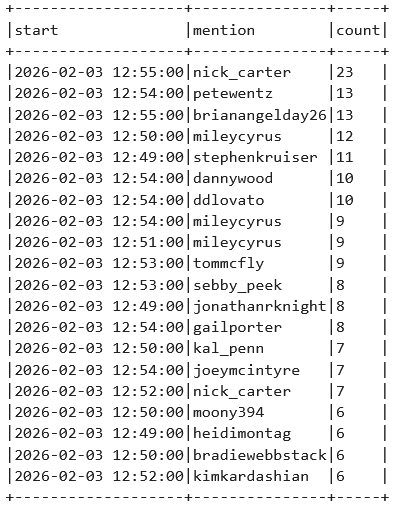
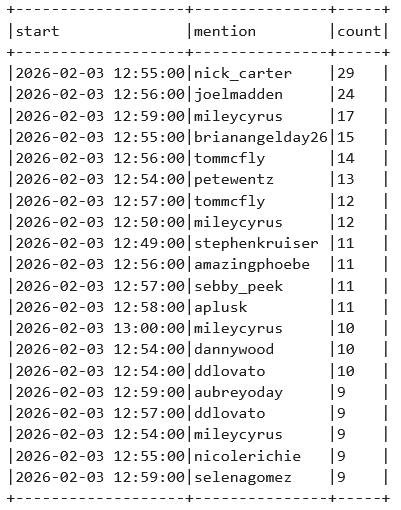

## 7. Analyse des utilisateurs

In [17]:
# ============================================================
# TODO [Exercice 7.1] : Top utilisateurs et profil sentiment
#
# Consigne : Calculez pour chaque utilisateur :
#            - le nombre de tweets
#            - le sentiment moyen
#            Triez par nombre de tweets decroissant.
#            Ecrivez vers un sink memoire nomme 'user_stats'
#
# Indice   : .groupBy("user").agg(count("*"), avg("sentiment_score"))
#            .orderBy(desc("nb_tweets"))
#
# Attendu  : Une query active avec colonnes user, nb_tweets, sentiment_moyen
# ============================================================

# --- SECURITE : Arrêt du flux précédent ---
# On s'assure qu'aucun flux du même nom ne tourne déjà
for q in spark.streams.active:
    if q.name == "user_stats":
        print(f"Arret du flux actif : {q.name}")
        q.stop()

# stats par utilisateur
user_stats_df = parsed.groupBy("user").agg(count("*").alias("nb_tweets"),avg("sentiment_score").alias("sentiment_moyen"))
#tri des resultats
sorted_user_stats = user_stats_df.orderBy(desc("nb_tweets"))

# lancement du flux
query_users = sorted_user_stats.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("user_stats") \
    .start()

26/02/08 21:31:31 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-fa7b03e2-1701-4e27-a21a-3884f8781f76. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/02/08 21:31:31 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [18]:
# vérifier si le flux tourne encore
print(query_users.isActive)

True


In [19]:
# stopper le flux
for q in spark.streams.active:
    if q.name == "user_stats":
        print(f"Arret du flux actif : {q.name}")
        q.stop()

Arret du flux actif : user_stats


In [20]:
time.sleep(15)
print("=== Top 15 utilisateurs les plus actifs ===")
spark.sql("SELECT * FROM user_stats ORDER BY nb_tweets DESC LIMIT 15").show(truncate=False)

print("=== Utilisateurs les plus positifs (min 3 tweets) ===")
spark.sql("SELECT * FROM user_stats WHERE nb_tweets >= 3 ORDER BY sentiment_moyen DESC LIMIT 10").show(truncate=False)

=== Top 15 utilisateurs les plus actifs ===
+----+---------+---------------+
|user|nb_tweets|sentiment_moyen|
+----+---------+---------------+
+----+---------+---------------+

=== Utilisateurs les plus positifs (min 3 tweets) ===
+----+---------+---------------+
|user|nb_tweets|sentiment_moyen|
+----+---------+---------------+
+----+---------+---------------+



**Après exécution de ces requêtes j'obtiens :**


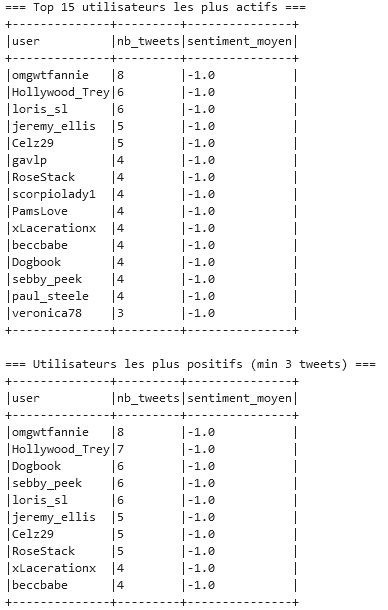

## 8. Systeme d'alerte

Detection d'une chute de sentiment dans une fenetre glissante de 1 minute (pas de 15 secondes). Alerte si le sentiment moyen est inferieur a -0.3 (plus de 65% de tweets negatifs).

In [21]:
# ============================================================
# TODO [Exercice 8.1] : Systeme d'alerte sentiment negatif
#
# Consigne : Creez une fenetre glissante de 1 minute avec un pas de 15 secondes.
#            Filtrez les fenetres ou le sentiment moyen est < -0.3
#            Ecrivez vers un sink memoire nomme 'alertes'
#
# Indice   : window("event_time", "1 minute", "15 seconds") pour la fenetre glissante
#            .filter(col("sentiment_moyen") < -0.3) pour le seuil d'alerte
#            Output mode "complete"
#
# Attendu  : Une query active montrant les fenetres en alerte
# ============================================================

# --- SECURITE : Arrêt du flux précédent ---
for q in spark.streams.active:
    if q.name == "alertes":
        q.stop()

# moyenne sur la fenetre glissante (transformation du dataset)
agg_alerts = parsed.groupBy(window("event_time", "1 minute", "15 seconds")).agg(avg("sentiment_score").alias("sentiment_moyen"))

# filtrage et mise en forme en gardant les fen où la moyenne est inférieure à -0,3
alerts_df = agg_alerts.filter(col("sentiment_moyen") < -0.3) \
    .select(
        col("window.start").alias("debut"),
        col("window.end").alias("fin"),
        col("sentiment_moyen")
    )

# lancement du flux
query_alerts = alerts_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("alertes") \
    .start()

26/02/08 21:31:58 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-be5353ad-96ee-4236-a4c1-39d0350e5c35. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/02/08 21:31:58 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [22]:
time.sleep(20)
result = spark.sql("SELECT * FROM alertes ORDER BY debut DESC")
if result.count() > 0:
    print("ALERTE ! Fenetres avec sentiment tres negatif :")
    result.show(10, truncate=False)
else:
    print("Aucune alerte pour le moment.")

ALERTE ! Fenetres avec sentiment tres negatif :
+-------------------+-------------------+---------------+
|debut              |fin                |sentiment_moyen|
+-------------------+-------------------+---------------+
|2026-02-08 21:32:15|2026-02-08 21:33:15|-1.0           |
|2026-02-08 21:32:00|2026-02-08 21:33:00|-1.0           |
|2026-02-08 21:31:45|2026-02-08 21:32:45|-1.0           |
|2026-02-08 21:31:30|2026-02-08 21:32:30|-1.0           |
|2026-02-08 21:31:15|2026-02-08 21:32:15|-1.0           |
+-------------------+-------------------+---------------+



**Avec cette requete d'alertes on obtient :**

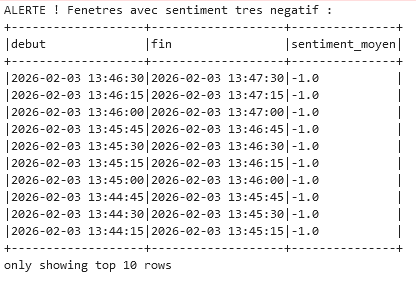

In [23]:
# stopper le flux
for q in spark.streams.active:
    if q.name == "alertes":
        q.stop()

26/02/08 21:32:21 ERROR TorrentBroadcast: Store broadcast broadcast_51 fail, remove all pieces of the broadcast


## 9. Watermarking

Le watermarking permet a Spark de gerer les donnees qui arrivent en retard et de liberer la memoire des anciennes fenetres.

In [24]:
# ============================================================
# TODO [Exercice 9.1] : Ajout du watermarking
#
# Consigne : Reprenez la requete d'alerte (exercice 8.1) mais ajoutez
#            un watermark de 1 minute sur le champ event_time.
#            Utilisez le mode "append" (au lieu de "complete").
#            Ecrivez vers un sink memoire nomme 'alertes_watermarked'
#
# Indice   : .withWatermark("event_time", "1 minute") avant le groupBy
#            Avec le watermark, le mode "append" devient possible
#            (les resultats sont emis une fois la fenetre finalisee)
#
# Attendu  : Une query active en mode append avec watermarking
# ============================================================

# --- SECURITE : Arrêt du flux précédent ---
for q in spark.streams.active:
    if q.name == "alertes_watermarked":
        q.stop()

#definition du watermark et de la fen
alerts_wm_df = parsed \
    .withWatermark("event_time", "1 minute") \
    .groupBy(window("event_time", "1 minute", "15 seconds")) \
    .agg(avg("sentiment_score").alias("sentiment_moyen"))

#garder que les alertes
final_df = alerts_wm_df.filter(col("sentiment_moyen") < -0.3)

# En mode "append" avec agrégation, le résultat n'est écrit QUE lorsque la fenêtre est fermée (finalisée).
# La fenêtre est fermée quand : Temps actuel > Fin de la fenêtre + Watermark.
query_wm = final_df.writeStream \
    .outputMode("append") \
    .format("memory") \
    .queryName("alertes_watermarked") \
    .start()

26/02/08 21:32:21 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-3d47f9ef-194a-4860-9c41-4a4b894eff74. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/02/08 21:32:21 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [25]:
# stopper le flux
for q in spark.streams.active:
    if q.name == "alertes_watermarked":
        q.stop()

In [26]:
time.sleep(90)  # Attendre que des fenetres soient finalisees
spark.sql("SELECT * FROM alertes_watermarked ORDER BY window.start DESC").show(10, truncate=False)

+------+---------------+
|window|sentiment_moyen|
+------+---------------+
+------+---------------+



On obtient ce résultat :

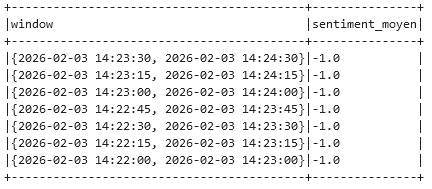

### Quel est l’effet du watermark sur la requête ?

Le watermark permet une gestion du retard, car Spark accepte les données jusqu'à 1 min de retard par rapport au temps maximum actuel.

Aussi, le mode "append" permet à Spark de ne sortir le résultat d'une fenêtre, que lorsqu'il est sûr qu'elle est terminée. Donc grâce au watermark, il sait qu'après "fin_fenetre + 1 min" il peut finaliser le calcul, l'afficher et libérer la mémoire.
C'est pour ça que les résultats apparaissent avec un petit décalage.

## 10. Arret des queries et de la session

In [27]:
# Arreter toutes les queries actives
for q in spark.streams.active:
    print(f"Arret de la query : {q.name}")
    q.stop()

print("Toutes les queries sont arretees.")
spark.stop()
print("SparkSession arretee.")

Toutes les queries sont arretees.
SparkSession arretee.
